In [48]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
import json
import os

Visualization parameters

In [49]:
results_parent_folder = "results/"
n_runs = 3 # default value of experiments

# Parameters of the experiment to analyze
num_labeled = 4000
dataset = "cifar10"
name_of_experiment = f"{dataset}_{num_labeled}_labels"

# Methods to analyze
methods = ["Supervised", "FixMatch", "MixMatch", "SequenceMatch","Full_Supervised"]

Visualization of performance for each run 

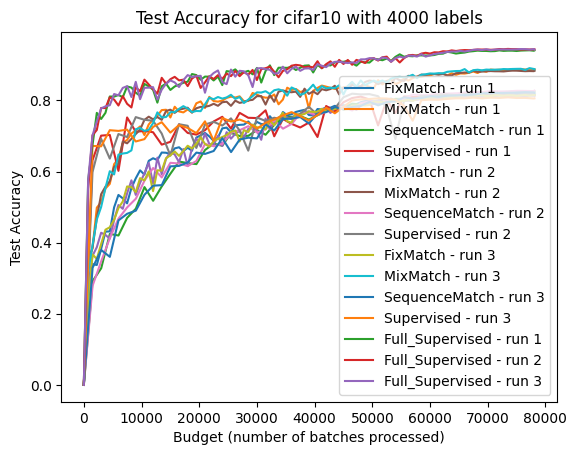

In [50]:
results_folder = os.path.join(results_parent_folder, name_of_experiment)
accs = {}
budgets = {}
for run in range(n_runs):
    path = results_folder + f"_run_{run+1}"
    if not os.path.exists(path):
        continue

    for file in os.listdir(path):
        method = file.split(".")[0]
        if method not in methods:
            continue
        with open(os.path.join(path, file), "r") as f:
            data = json.load(f)
            accs[method] = accs.get(method, []) + [data["test_acc"]]
            budgets[method] = budgets.get(method, []) + [data["budget"]]
        # Plot the results
        plt.plot(data['budget'], data["test_acc"], label=f"{method} - run {run+1}")


if "Full_Supervised" in methods:
    # Add fully supervised baseline
    for run in range(n_runs):
        path = f"results/{dataset}_full_sup_run_" + str(run+1)
        if not os.path.exists(path):
            continue
        with open(path+"/Full_Supervised.json", "r") as f:
            data = json.load(f)
            accs["Full_Supervised"] = accs.get("Full_Supervised", []) + [data["test_acc"]]
            budgets["Full_Supervised"] = budgets.get("Full_Supervised", []) + [data["budget"]]
        plt.plot(data['budget'], data["test_acc"], label=f"Full_Supervised - run {run+1}")

plt.xlabel("Budget (number of batches processed)")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.show()

Max Accuracy and Minimum Error Rate for each method

In [51]:
for method, acc in accs.items():
    if method not in methods:
        continue
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    # get max accuracy of each run
    max_acc = np.max(acc, axis=1)
    mean_max_acc = np.mean(max_acc)
    std_max_acc = np.std(max_acc)
    print(f"{method}: Max Test Accuracy = {mean_max_acc*100:.4f} ± {std_max_acc*100:.4f}")
    # print error rate   mean_error_rate = 1 - mean_max_acc
    mean_error_rate = 1 - mean_max_acc
    std_error_rate = std_max_acc
    print(f"{method}: Error Rate = {mean_error_rate*100:.4f} ± {std_error_rate*100:.4f}")
    print("\n")

FixMatch: Max Test Accuracy = 81.5967 ± 0.2288
FixMatch: Error Rate = 18.4033 ± 0.2288


MixMatch: Max Test Accuracy = 88.7333 ± 0.2910
MixMatch: Error Rate = 11.2667 ± 0.2910


SequenceMatch: Max Test Accuracy = 82.5400 ± 0.1757
SequenceMatch: Error Rate = 17.4600 ± 0.1757


Supervised: Max Test Accuracy = 81.4700 ± 0.4492
Supervised: Error Rate = 18.5300 ± 0.4492


Full_Supervised: Max Test Accuracy = 94.3300 ± 0.1705
Full_Supervised: Error Rate = 5.6700 ± 0.1705




Budget vs Accuracy for each method and run

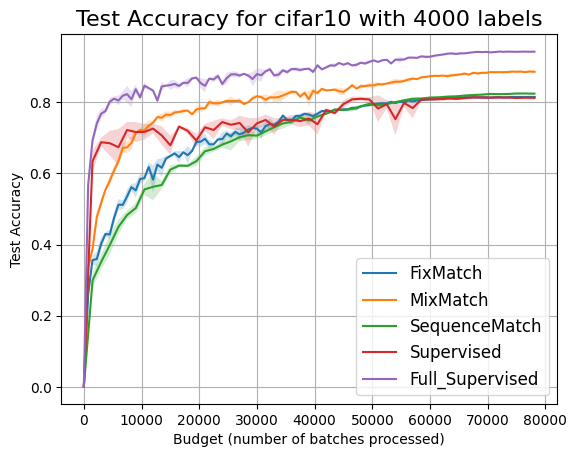

In [52]:
budgets_copy = budgets.copy()  # Create a copy to avoid modifying the original budgets
for method, acc in accs.items():
    if method not in methods:
        continue
    # Handle the case where the acc has different lengths (e.g., due to missing runs)
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    budgets_copy[method] = budgets[method][0][:acc.shape[1]]  # Truncate budgets to match acc length
    # Compute mean and std
    mean_acc = np.mean(acc, axis=0)
    std_acc = np.std(acc, axis=0)
    # Plot the results
    plt.plot(budgets_copy[method], mean_acc, label=f"{method}")
    plt.fill_between(budgets_copy[method], mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)
plt.xlabel("Budget (number of batches processed)")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.show()

Step-oriented evaluation of performance for each method

In [53]:
# Define the budget per iteration for each method (number of batches processed per iteration)
budget_per_iteration = {
    "Supervised": 1,
    "Full_Supervised": 1,
    "MixMatch": 3,
    "FixMatch": 15,
    "FixMatch_mu_1": 3,
    "SequenceMatch": 22,
    "SequenceMatch_mu_1": 4,
}

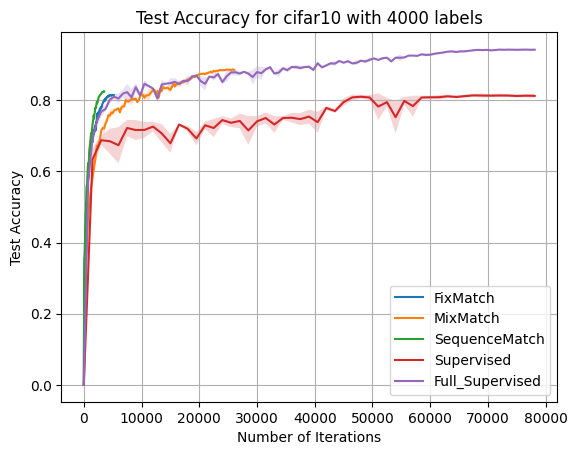

In [54]:
steps = {}
budgets_copy = budgets.copy()  # Create a copy to avoid modifying the original budgets
for method, acc in accs.items():
    if method not in methods:
        continue
    # Handle the case where the acc has different lengths (e.g., due to missing runs)
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    steps[method] = np.array(budgets_copy[method][0][:acc.shape[1]]) / budget_per_iteration[method]  # Truncate budgets to match acc length
    # Compute mean and std
    mean_acc = np.mean(acc, axis=0)
    std_acc = np.std(acc, axis=0)
    # Plot the results
    plt.plot(steps[method], mean_acc, label=f"{method}")
    plt.fill_between(steps[method], mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)
plt.xlabel("Number of Iterations")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.grid()
plt.show()

Truncated to the shortest length of runs for each method for better visualization and comparison

In [55]:
steps = {}
budgets_copy = budgets.copy()  # Create a copy to avoid modifying the original budgets
min_steps = np.inf

for method, acc in accs.items():
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    steps_method = np.array(budgets_copy[method][0][:acc.shape[1]]) / budget_per_iteration[method]  # Truncate budgets to match acc length
    min_steps = min(min_steps, steps_method.max())

print(f"Minimum number of steps across all methods: {min_steps}")

Minimum number of steps across all methods: 3550.0


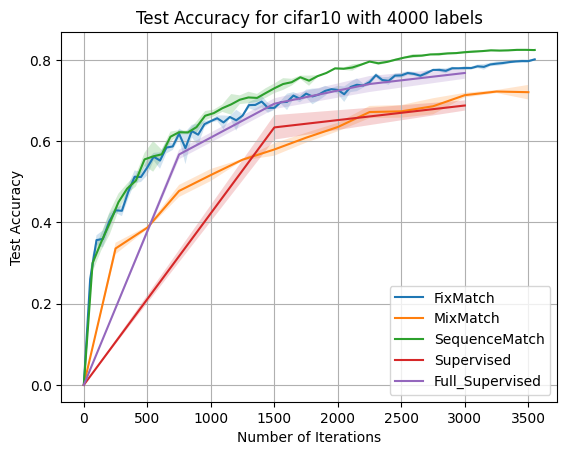

In [56]:
# Truncate steps and acc to the minimum number of steps
for method, acc in accs.items():
    acc = np.array([a[:min(map(len, acc))] for a in acc])  # Truncate to the shortest length
    steps_method = np.array(budgets_copy[method][0][:acc.shape[1]]) / budget_per_iteration[method]  # Truncate budgets to match acc length
    acc_truncated = acc[:, steps_method <= min_steps]
    steps_truncated = steps_method[steps_method <= min_steps]
    # Compute mean and std
    mean_acc = np.mean(acc_truncated, axis=0)
    std_acc = np.std(acc_truncated, axis=0)
    # Plot the results
    plt.plot(steps_truncated, mean_acc, label=f"{method}")
    plt.fill_between(steps_truncated, mean_acc - std_acc, mean_acc + std_acc, alpha=0.2)
plt.xlabel("Number of Iterations")
plt.ylabel("Test Accuracy")
plt.title(f"Test Accuracy for {dataset} with {num_labeled} labels")
plt.legend()
plt.grid()
plt.show()